In [1]:
!pip install -U scikit-learn==1.5.0
!pip install -U imbalanced-learn==0.13.0
!pip install polars[numpy,pandas,pyarrow] --no-index --find-links=file:///kaggle/input/polars-and-duckdb/kaggle/working/mysitepackages/polars_pkg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 53.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 7.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Looking in links: file:///kaggle/input/polars-and-duckdb/kaggle/working/mysitepackages/polars_pkg
Processing /kaggle/input/polars-and-duckdb/kaggle/working/mysitepackages/polars_pkg/polars-0.20.16-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl


In [2]:
import sklearn
import imblearn
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import glob
import os
import polars as pl
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import pickle
import ctypes
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

print("scikit-learn version:", sklearn.__version__)
print("imblearn version:", imblearn.__version__)

E0000 00:00:1746883285.082760      10 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:230


scikit-learn version: 1.5.0
imblearn version: 0.13.0


In [3]:
# detect TPUs
tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
tf.tpu.experimental.initialize_tpu_system(tpu)
tpu_strategy = tf.distribute.TPUStrategy(tpu)

print("Number of accelerators: ", tpu_strategy.num_replicas_in_sync)

INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local


I0000 00:00:1746883305.941139      10 service.cc:148] XLA service 0x57d70cf38960 initialized for platform TPU (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746883305.941183      10 service.cc:156]   StreamExecutor device (0): TPU, 2a886c8
I0000 00:00:1746883305.941187      10 service.cc:156]   StreamExecutor device (1): TPU, 2a886c8
I0000 00:00:1746883305.941189      10 service.cc:156]   StreamExecutor device (2): TPU, 2a886c8
I0000 00:00:1746883305.941192      10 service.cc:156]   StreamExecutor device (3): TPU, 2a886c8
I0000 00:00:1746883305.941194      10 service.cc:156]   StreamExecutor device (4): TPU, 2a886c8
I0000 00:00:1746883305.941197      10 service.cc:156]   StreamExecutor device (5): TPU, 2a886c8
I0000 00:00:1746883305.941199      10 service.cc:156]   StreamExecutor device (6): TPU, 2a886c8
I0000 00:00:1746883305.941201      10 service.cc:156]   StreamExecutor device (7): TPU, 2a886c8


INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:4, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:5, TPU, 0, 0)
I

In [56]:
feature_file_path = '/kaggle/input/birdclef-2025-features-labels-v1/extracted_train_feat_five_sec_v5_2025'
label_file_path = '/kaggle/input/birdclef-2025-features-labels-v1/labels_five_sec_v5_2025'

missing_classes_feature_file_path = '/kaggle/input/missing-classes-features-labels/late_inclusion_features_2025'
missing_classes_label_file_path = '/kaggle/input/missing-classes-features-labels/late_inclusion_labels_2025'

In [57]:
# Check the pickled data right after loading
def inspect_pickled_data(features, labels, name="Dataset"):
    print(f"\n{name} Inspection:")
    print("Features:")
    print("- dtype:", features.dtype)
    print("- shape:", features.shape)
    print("- min:", np.min(features))
    print("- max:", np.max(features))
    print("- mean:", np.mean(features))
    print("- std:", np.std(features))
    print("- any nan:", np.isnan(features).any())
    print("- any inf:", np.isinf(features).any())
    
    print("\nLabels:")
    print("- dtype:", labels.dtype)
    print("- shape:", labels.shape)
    print("- unique values:", np.unique(labels))
    print("- min:", np.min(labels))
    print("- max:", np.max(labels))
    print("- any nan:", np.isnan(labels).any())
    print("- any inf:", np.isinf(labels).any())
    
    # Print first few samples
    print("\nFirst few labels:", labels[:5])
    print("Label distribution:")
    unique, counts = np.unique(labels, return_counts=True)
    for u, c in zip(unique[:5], counts[:5]):  # Show first 5 classes
        print(f"Class {u}: {c} samples")
    print("...")

In [58]:
# Inspect each pickle file separately
with open(feature_file_path, "rb") as file:
    pickled_extracted_features_five_sec = pickle.load(file)
with open(label_file_path, "rb") as file:
    labels_five_sec = pickle.load(file)

inspect_pickled_data(
    pickled_extracted_features_five_sec, 
    labels_five_sec, 
    "Main Dataset"
)


Main Dataset Inspection:
Features:
- dtype: float32
- shape: (180142, 40)
- min: -1029.1322
- max: 307.16528
- mean: -7.88166
- std: 62.065163
- any nan: False
- any inf: False

Labels:
- dtype: int64
- shape: (180142,)
- unique values: [  2   3   4   5   6  10  11  12  13  14  15  16  18  19  20  21  22  23
  24  25  26  27  28  29  30  31  32  34  35  36  37  38  40  41  42  43
  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  60  61  62
  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80
  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116
 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134
 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152
 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170
 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188
 189 190 191 192 193 194 195 196

In [59]:
with open(missing_classes_feature_file_path, "rb") as file:
    pickled_missing_classes_features_five_sec = pickle.load(file)
with open(missing_classes_label_file_path, "rb") as file:
    labels_missing_classes_five_sec = pickle.load(file)

inspect_pickled_data(
    pickled_missing_classes_features_five_sec, 
    labels_missing_classes_five_sec, 
    "Missing Classes Dataset"
)


Missing Classes Dataset Inspection:
Features:
- dtype: float32
- shape: (620, 40)
- min: -721.8137
- max: 151.68137
- mean: -4.5757794
- std: 59.934452
- any nan: False
- any inf: False

Labels:
- dtype: int64
- shape: (620,)
- unique values: [ 0  1  7  8 17 33 39 59]
- min: 0
- max: 59
- any nan: False
- any inf: False

First few labels: [17 17 17 17 17]
Label distribution:
Class 0: 38 samples
Class 1: 83 samples
Class 7: 59 samples
Class 8: 140 samples
Class 17: 88 samples
...


In [60]:
# Inspect after concatenation
x_five_sec = np.vstack([pickled_extracted_features_five_sec, pickled_missing_classes_features_five_sec])
y_five_sec = np.concatenate([labels_five_sec, labels_missing_classes_five_sec], axis=0)

inspect_pickled_data(x_five_sec, y_five_sec, "Combined Dataset")


Combined Dataset Inspection:
Features:
- dtype: float32
- shape: (180762, 40)
- min: -1029.1322
- max: 307.16528
- mean: -7.8703213
- std: 62.058254
- any nan: False
- any inf: False

Labels:
- dtype: int64
- shape: (180762,)
- unique values: [  0   1   2   3   4   5   6   7   8  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 1

In [61]:
print("Combined features shape:", x_five_sec.shape)
print("Combined labels shape:", y_five_sec.shape)

Combined features shape: (180762, 40)
Combined labels shape: (180762,)


In [63]:
ros = RandomOverSampler(random_state=42, sampling_strategy='minority')
features_resampled, labels_resampled = ros.fit_resample(x_five_sec, y_five_sec)

inspect_pickled_data(features_resampled, labels_resampled, "Resampled Dataset")

print("Resampled features shape:", features_resampled.shape)
print("Resampled labels shape:", labels_resampled.shape)


Resampled Dataset Inspection:
Features:
- dtype: float32
- shape: (186377, 40)
- min: -1029.1322
- max: 307.16528
- mean: -7.867526
- std: 62.314625
- any nan: False
- any inf: False

Labels:
- dtype: int64
- shape: (186377,)
- unique values: [  0   1   2   3   4   5   6   7   8  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 1

In [64]:
shuffle_idx = np.random.permutation(len(features_resampled))
X_combined = features_resampled[shuffle_idx]
y_combined = labels_resampled[shuffle_idx]

In [76]:
total_unique_labels = np.unique(y_combined)
num_classes = len(total_unique_labels)
print(f"Total number of unique classes in complete dataset: {num_classes}")

Total number of unique classes in complete dataset: 205


In [65]:
inspect_pickled_data(X_combined, y_combined, "shuffled Dataset")


shuffled Dataset Inspection:
Features:
- dtype: float32
- shape: (186377, 40)
- min: -1029.1322
- max: 307.16528
- mean: -7.867528
- std: 62.3146
- any nan: False
- any inf: False

Labels:
- dtype: int64
- shape: (186377,)
- unique values: [  0   1   2   3   4   5   6   7   8  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 

In [66]:
def prepare_dataset_old(X, y, batch_size=32):
    """
    Convert numpy arrays to tf.data.Dataset with batching and prefetching
    """
    min_label = np.min(y)
    max_label = np.max(y)
    unique_labels = np.unique(y)
    print(f"****** dataset size**********: {X.shape}")
    print(f"Label range: {min_label} to {max_label}")
    print(f"Number of unique labels: {len(unique_labels)}")
    #print(f"Unique labels: {unique_labels}")
    
    # Robust normalization using min-max scaling instead of standard scaling
    """X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)
    X_normalized = (X - X_min) / (X_max - X_min + 1e-8)"""

    # Normalize features
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0) + 1e-8
    X_normalized = (X - X_mean) / X_std

    # Convert to float32 for TPU
    X_normalized = X_normalized.astype(np.float32)
    
    # Ensure y is 1D array of integers
    y = np.asarray(y).astype(np.int32).ravel()
    
    # Get number of classes
    num_classes = max_label + 1
    print(f"Number of unique classes in this split: {num_classes}")
    
    # Double check normalization
    print("After normalization:")
    print("Min:", np.min(X_normalized))
    print("Max:", np.max(X_normalized))
    print("Mean:", np.mean(X_normalized))
    print("Std:", np.std(X_normalized))
    
    # Convert to one-hot encoding
    y_onehot = tf.keras.utils.to_categorical(y, num_classes=num_classes).astype(np.float32)
    print(f"One-hot encoded shape: {y_onehot.shape}")
    
    # Verify one-hot encoding
    print("Sample of one-hot encoded labels:")
    print(y_onehot[:5])
    print("\nOriginal labels:", y[:5])
    
    # Create tf.data.Dataset
    dataset = tf.data.Dataset.from_tensor_slices((X_normalized, y_onehot))
    #dataset = tf.data.Dataset.from_tensor_slices((X_normalized, y))
    dataset = dataset.cache()  # Cache the data in memory
    dataset = dataset.shuffle(buffer_size=len(X))  # Shuffle the entire dataset
    dataset = dataset.batch(batch_size)  # Batch the data
    dataset = dataset.prefetch(tf.data.AUTOTUNE)  # Prefetch next batch
    
    return dataset

In [77]:
def prepare_dataset(X, y, batch_size=32):
    """
    Improved dataset preparation with proper normalization and label remapping
    """
    # 1. First, let's remap the labels to be continuous from 0 to num_classes-1
    unique_labels = np.unique(y)
    label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
    y_remapped = np.array([label_map[label] for label in y])
    
    print(f"Remapped {len(unique_labels)} classes to range 0-{len(unique_labels)-1}")
    
    # 2. Robust feature normalization
    # First, clip extreme values (outside 3 standard deviations)
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_clipped = np.clip(X, mean - 3*std, mean + 3*std)
    
    # Then apply robust scaling
    X_normalized = (X_clipped - np.mean(X_clipped, axis=0)) / (np.std(X_clipped, axis=0) + 1e-8)
    
    # Convert to float32 for TPU
    X_normalized = X_normalized.astype(np.float32)
    
    # 3. Create one-hot encoded labels with float32 dtype
    #num_classes = len(unique_labels)
    y_onehot = tf.keras.utils.to_categorical(y_remapped, num_classes=num_classes)
    y_onehot = y_onehot.astype(np.float32)
    
    # 4. Create and configure dataset
    dataset = tf.data.Dataset.from_tensor_slices((X_normalized, y_onehot))
    dataset = dataset.cache()
    dataset = dataset.shuffle(buffer_size=len(X), seed=42)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset, label_map

In [78]:
X_train, X_val, y_train, y_val = train_test_split(X_combined, y_combined, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.2, random_state=42)

In [93]:
# Prepare datasets
train_dataset, label_map = prepare_dataset(X_train, y_train, batch_size=128)
val_dataset, _ = prepare_dataset(X_val, y_val, batch_size=12)
test_dataset, _ = prepare_dataset(X_test, y_test, batch_size=128)

Remapped 204 classes to range 0-203
Remapped 203 classes to range 0-202
Remapped 196 classes to range 0-195


In [81]:
# Verify the improved datasets
def verify_improved_dataset(dataset, name="Dataset"):
    print(f"\nVerifying {name}:")
    for features, labels in dataset.take(1):
        print("Features:")
        print("- shape:", features.shape)
        print("- dtype:", features.dtype)
        print("- min:", tf.reduce_min(features).numpy())
        print("- max:", tf.reduce_max(features).numpy())
        print("- mean:", tf.reduce_mean(features).numpy())
        print("- std:", tf.sqrt(tf.reduce_mean(tf.square(features - tf.reduce_mean(features)))).numpy())
        
        print("\nLabels:")
        print("- shape:", labels.shape)
        print("- dtype:", labels.dtype)
        print("- sum per row (should be 1):", tf.reduce_sum(labels, axis=1)[:5].numpy())
        break

verify_improved_dataset(train_dataset, "Training Dataset")
verify_improved_dataset(val_dataset, "Validation Dataset")
verify_improved_dataset(test_dataset, "Test Dataset")


Verifying Training Dataset:
Features:
- shape: (64, 40)
- dtype: <dtype: 'float32'>
- min: -3.078439
- max: 3.073868
- mean: 0.018549874
- std: 1.017488

Labels:
- shape: (64, 205)
- dtype: <dtype: 'float32'>
- sum per row (should be 1): [1. 1. 1. 1. 1.]

Verifying Validation Dataset:
Features:
- shape: (64, 40)
- dtype: <dtype: 'float32'>
- min: -3.0769234
- max: 3.0726857
- mean: 0.0017722298
- std: 0.96699053

Labels:
- shape: (64, 205)
- dtype: <dtype: 'float32'>
- sum per row (should be 1): [1. 1. 1. 1. 1.]

Verifying Test Dataset:
Features:
- shape: (64, 40)
- dtype: <dtype: 'float32'>
- min: -3.0628684
- max: 3.0659509
- mean: 0.062761545
- std: 0.93091565

Labels:
- shape: (64, 205)
- dtype: <dtype: 'float32'>
- sum per row (should be 1): [1. 1. 1. 1. 1.]


In [74]:
def create_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.BatchNormalization(name='batch_norm_input'),
        
        layers.Dense(256, kernel_initializer='he_normal', name='dense_1'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(192, kernel_initializer='he_normal', name='dense_2'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        
        layers.Dense(num_classes, name='output')  # Linear activation for logits
    ])
    return model

In [30]:
input_shape = (X_train.shape[1],)  # Will be (40,)
num_classes = 206
print(input_shape)

(40,)


In [82]:
# Compile with proper configuration
with tpu_strategy.scope():
    model = create_model(input_shape=(40,), num_classes=num_classes)
    
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        clipnorm=1.0,
        epsilon=1e-7
    )
    
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(
            from_logits=True,
            label_smoothing=0.1
        ),
        metrics=['accuracy']
    )

In [83]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_norm_input                │ (None, 40)             │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 192)            │        49,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 205)            │        39,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,357 (395.93 KB)

 Trainable params: 100,381 (392.11 KB)

 Non-trainable params: 976 (3.81 KB)

In [87]:
def verify_batch(dataset):
    for features, labels in dataset.take(1):
        print("\nBatch verification:")
        print(f"Features shape: {features.shape}")
        print("\nSample features from batch:")
        print(features[:5])
        print(f"Labels shape: {labels.shape}")
        print(f"Features dtype: {features.dtype}")
        print(f"Labels dtype: {labels.dtype}")
        print("\nSample labels from batch:")
        print(labels[:5])
        print("\nVerifying one-hot encoding (sum should be 1 for each row):")
        print(tf.reduce_sum(labels, axis=1)[:5])
        break

# Use this after creating your datasets
verify_batch(train_dataset)
verify_batch(val_dataset)


Batch verification:
Features shape: (64, 40)

Sample features from batch:
tf.Tensor(
[[-8.33892465e-01  3.34611148e-01  1.10885942e+00  3.82737696e-01
   7.64636219e-01  7.47638762e-01  1.06400573e+00  7.63793170e-01
   4.75706518e-01  6.02381706e-01 -1.05074026e-01 -1.42666236e-01
  -5.55213392e-02 -5.25075376e-01 -9.88309205e-01 -3.35294217e-01
  -4.91330713e-01  7.71810412e-02 -2.18564048e-01  1.63533032e-01
  -9.65268850e-01 -1.11172664e+00 -9.65201557e-01 -2.61882991e-01
  -7.09973156e-01  2.89043710e-02 -5.19751608e-01 -1.38749421e-01
  -5.18179476e-01  6.95395231e-01 -4.95872796e-01 -4.11528721e-02
  -9.77039754e-01 -1.23498070e+00 -1.19656408e+00 -7.47587681e-01
  -2.19369102e+00 -1.16551638e+00 -1.86276770e+00 -8.63475323e-01]
 [ 1.55998260e-01  6.47213086e-02  1.01146483e+00 -1.13361284e-01
   1.20669889e+00  4.95287497e-03  9.48380113e-01  6.75774932e-01
   6.67972386e-01  1.17505121e+00  5.20012438e-01  7.22992480e-01
   4.82275277e-01  1.11587858e+00  2.78606147e-01  5.20

In [85]:
# Add this before training to verify data types
for features, labels in train_dataset.take(1):
    print("Features dtype:", features.dtype)
    print("Labels dtype:", labels.dtype)
    print("Features shape:", features.shape)
    print("Labels shape:", labels.shape)
    print("\nFeatures min/max:", tf.reduce_min(features).numpy(), tf.reduce_max(features).numpy())
    print("Labels sum per row (should be 1):", tf.reduce_sum(labels, axis=1)[:5].numpy())

Features dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'float32'>
Features shape: (64, 40)
Labels shape: (64, 205)

Features min/max: -3.0759485 3.077651
Labels sum per row (should be 1): [1. 1. 1. 1. 1.]


In [88]:
# Debug data values
def inspect_batch_values(dataset, num_batches=2):
    print("\nDetailed Batch Inspection:")
    for batch_idx, (x, y) in enumerate(dataset.take(num_batches)):
        print(f"\nBatch {batch_idx + 1}:")
        print("Features:")
        print("- shape:", x.shape)
        print("- min:", tf.reduce_min(x).numpy())
        print("- max:", tf.reduce_max(x).numpy())
        print("- mean:", tf.reduce_mean(x).numpy())
        print("- any nan:", tf.reduce_any(tf.math.is_nan(x)).numpy())
        print("- any inf:", tf.reduce_any(tf.math.is_inf(x)).numpy())
        
        print("\nLabels:")
        print("- shape:", y.shape)
        print("- unique values:", np.unique(y.numpy()))
        print("- row sums:", tf.reduce_sum(y, axis=1).numpy()[:5])
        print("- any nan:", tf.reduce_any(tf.math.is_nan(y)).numpy())
        print("- any inf:", tf.reduce_any(tf.math.is_inf(y)).numpy())
        
        # Print a few actual values
        print("\nSample feature values (first row, first 5 values):", x[0, :5].numpy())
        print("Sample label values (first row, first 5 values):", y[0, :5].numpy())

inspect_batch_values(train_dataset)


Detailed Batch Inspection:

Batch 1:
Features:
- shape: (64, 40)
- min: -3.0828488
- max: 3.0805607
- mean: -0.008172954
- any nan: False
- any inf: False

Labels:
- shape: (64, 205)
- unique values: [0. 1.]
- row sums: [1. 1. 1. 1. 1.]
- any nan: False
- any inf: False

Sample feature values (first row, first 5 values): [-0.6561821  -0.15842216  0.82617867  0.41817153 -0.00368237]
Sample label values (first row, first 5 values): [0. 0. 0. 0. 0.]

Batch 2:
Features:
- shape: (64, 40)
- min: -3.0828488
- max: 3.0805607
- mean: -0.021673437
- any nan: False
- any inf: False

Labels:
- shape: (64, 205)
- unique values: [0. 1.]
- row sums: [1. 1. 1. 1. 1.]
- any nan: False
- any inf: False

Sample feature values (first row, first 5 values): [ 0.24701628  0.400525   -1.4455545  -0.01512538 -0.47115743]
Sample label values (first row, first 5 values): [0. 0. 0. 0. 0.]


In [91]:
class DebugCallback(tf.keras.callbacks.Callback):
    def on_batch_end(self, batch, logs=None):
        if batch < 5 or (logs and np.isnan(logs.get('loss', 0))):
            print(f"\nBatch {batch} results:")
            print("Loss:", logs.get('loss', 'N/A'))
            print("Accuracy:", logs.get('accuracy', 'N/A'))
            if np.isnan(logs.get('loss', 0)):
                print("NaN loss detected!")

# Let's create a complete minimal test with debugging:

# 1. Create simple model
def create_simple_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(64, activation='relu', 
                    kernel_initializer='he_normal',
                    kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        layers.Dense(num_classes)
    ])
    return model

# 2. Compile with basic settings
with tpu_strategy.scope():
    model = create_simple_model(input_shape=(40,), num_classes=num_classes)
    
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-5,
        clipvalue=0.5,
        epsilon=1e-7
    )
    
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(
            from_logits=True,
            label_smoothing=0.0
        ),
        metrics=['accuracy']
    )

# 3. Add debug prints before training
print("\nModel Summary:")
model.summary()

print("\nChecking first batch of training data:")
for x_batch, y_batch in train_dataset.take(1):
    print("\nFeatures (X):")
    print("- shape:", x_batch.shape)
    print("- dtype:", x_batch.dtype)
    print("- min:", tf.reduce_min(x_batch).numpy())
    print("- max:", tf.reduce_max(x_batch).numpy())
    print("- mean:", tf.reduce_mean(x_batch).numpy())
    print("- any nan:", tf.reduce_any(tf.math.is_nan(x_batch)).numpy())
    print("- any inf:", tf.reduce_any(tf.math.is_inf(x_batch)).numpy())
    
    print("\nLabels (y):")
    print("- shape:", y_batch.shape)
    print("- dtype:", y_batch.dtype)
    print("- unique values:", np.unique(y_batch.numpy()))
    print("- row sums:", tf.reduce_sum(y_batch, axis=1).numpy()[:5])
    print("- any nan:", tf.reduce_any(tf.math.is_nan(y_batch)).numpy())
    print("- any inf:", tf.reduce_any(tf.math.is_inf(y_batch)).numpy())
    
    # Test forward pass
    print("\nTesting forward pass:")
    predictions = model(x_batch, training=False)
    print("Predictions:")
    print("- shape:", predictions.shape)
    print("- min:", tf.reduce_min(predictions).numpy())
    print("- max:", tf.reduce_max(predictions).numpy())
    print("- any nan:", tf.reduce_any(tf.math.is_nan(predictions)).numpy())
    
    # Test loss calculation
    print("\nTesting loss calculation:")
    loss = tf.keras.losses.categorical_crossentropy(
        y_batch, predictions, from_logits=True
    )
    print("Loss:")
    print("- shape:", loss.shape)
    print("- mean:", tf.reduce_mean(loss).numpy())
    print("- any nan:", tf.reduce_any(tf.math.is_nan(loss)).numpy())

# 4. Train with minimal steps
callbacks = [
    DebugCallback(),
    tf.keras.callbacks.TerminateOnNaN()
]

print("\nStarting training:")
history = model.fit(
    train_dataset,
    epochs=1,
    steps_per_epoch=50,  # Limit steps for testing
    callbacks=callbacks,
    verbose=1
)


Model Summary:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 205)            │        13,325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,949 (62.30 KB)

 Trainable params: 15,949 (62.30 KB)

 Non-trainable params: 0 (0.00 B)


Checking first batch of training data:

Features (X):
- shape: (64, 40)
- dtype: <dtype: 'float32'>
- min: -3.0828488
- max: 3.0844817
- mean: -0.010796895
- any nan: False
- any inf: False

Labels (y):
- shape: (64, 205)
- dtype: <dtype: 'float32'>
- unique values: [0. 1.]
- row sums: [1. 1. 1. 1. 1.]
- any nan: False
- any inf: False

Testing forward pass:
Predictions:
- shape: (64, 205)
- min: -3.8078446
- max: 4.461598
- any nan: False

Testing loss calculation:
Loss:
- shape: (64,)
- mean: 5.6859593
- any nan: False

Starting training:


I0000 00:00:1746889959.517711      10 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:14116671135824087589
I0000 00:00:1746889959.952739    1023 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(18413534673988239025), session_name()
I0000 00:00:1746889960.307258    1023 tpu_compile_op_common.cc:245] Compilation of 18413534673988239025 with session name  took 354.473123ms and succeeded
I0000 00:00:1746889960.309996    1023 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(18413534673988239025), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_14116671135824087589", property.function_library_fingerprint = 13218071077185953604, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap


Batch 0 results:
Loss: 5.625964164733887
Accuracy: 0.0
 1/50 ━━━━━━━━━━━━━━━━━━━━ 1:38 2s/step - accuracy: 0.0000e+00 - loss: 5.6260
Batch 1 results:
Loss: 5.622414588928223
Accuracy: 0.0

Batch 2 results:
Loss: 5.624518871307373
Accuracy: 0.0

Batch 3 results:
Loss: 5.624373912811279
Accuracy: 2.6709401936386712e-05

Batch 4 results:
Loss: 5.624358177185059
Accuracy: 3.0041659556445666e-05
35/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 2.7371e-05 - loss: 5.6244
Batch 40 results:
Loss: nan
Accuracy: 0.0
NaN loss detected!
Batch 40: Invalid loss, terminating training
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 2.7571e-05 - loss: nan   


In [94]:
def create_tpu_optimized_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # TPU-friendly normalization (using tf.keras layers instead of Lambda)
        layers.Rescaling(scale=0.1),
        
        # First dense layer with TPU-friendly settings
        layers.Dense(32,
                    activation=None,  # Separate activation for TPU
                    kernel_initializer='glorot_uniform',
                    bias_initializer='zeros',
                    kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        layers.ReLU(),  # Separate ReLU is more TPU-friendly
        
        # Output layer
        layers.Dense(num_classes,
                    kernel_initializer='glorot_uniform',
                    bias_initializer='zeros',
                    kernel_regularizer=tf.keras.regularizers.l2(1e-5))
    ])
    return model

# TPU-specific training setup
with tpu_strategy.scope():
    # Create and compile model
    model = create_tpu_optimized_model(input_shape=(40,), num_classes=num_classes)
    
    # Use a learning rate schedule
    initial_learning_rate = 1e-7  # Start extremely small
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate,
        decay_steps=100,
        decay_rate=1.1,  # Slightly increase over time if stable
        staircase=True
    )
    
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr_schedule,
        clipvalue=0.5,
        epsilon=1e-8,
        beta_1=0.9,
        beta_2=0.999
    )
    
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(
            from_logits=True,
            reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE
        ),
        metrics=['accuracy']
    )

# Modified callback for TPU
class TPUDebugCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.last_weights = None
        
    def on_batch_begin(self, batch, logs=None):
        if batch < 5:
            # Store weights for comparison
            self.last_weights = [tf.identity(w) for w in self.model.get_weights()]
    
    def on_batch_end(self, batch, logs=None):
        if batch < 5 or (logs and np.isnan(logs.get('loss', 0))):
            print(f"\nBatch {batch}:")
            print(f"Loss: {logs.get('loss', 'N/A')}")
            print(f"Accuracy: {logs.get('accuracy', 'N/A')}")
            
            # Check weight updates if we have previous weights
            if self.last_weights is not None:
                current_weights = self.model.get_weights()
                for i, (last_w, current_w) in enumerate(zip(self.last_weights, current_weights)):
                    weight_diff = np.mean(np.abs(current_w - last_w))
                    print(f"Layer {i} mean weight update: {weight_diff}")
            
            self.last_weights = [tf.identity(w) for w in self.model.get_weights()]

# TPU-friendly callbacks
callbacks = [
    TPUDebugCallback(),
    tf.keras.callbacks.TerminateOnNaN(),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=3,
        restore_best_weights=True
    )
]

# First, verify the dataset is TPU-optimized
print("Verifying dataset:")
for x_batch, y_batch in train_dataset.take(1):
    print("Features dtype:", x_batch.dtype)
    print("Labels dtype:", y_batch.dtype)
    print("Features shape:", x_batch.shape)
    print("Labels shape:", y_batch.shape)

# Train with very limited steps initially
print("\nStarting training:")
history = model.fit(
    train_dataset,
    epochs=1,
    steps_per_epoch=50,
    callbacks=callbacks,
    verbose=1
)

Verifying dataset:
Features dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'float32'>
Features shape: (128, 40)
Labels shape: (128, 205)

Starting training:


I0000 00:00:1746890299.159842      10 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:14039322894856745115
I0000 00:00:1746890299.648179    1002 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(3040616789096678501), session_name()
I0000 00:00:1746890300.031396    1002 tpu_compile_op_common.cc:245] Compilation of 3040616789096678501 with session name  took 383.170238ms and succeeded
I0000 00:00:1746890300.033655    1002 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(3040616789096678501), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_14039322894856745115", property.function_library_fingerprint = 1038811297762981387, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z


Batch 0:
Loss: 5.324930191040039
Accuracy: 0.0
Layer 0 mean weight update: 9.98757769821168e-08
Layer 1 mean weight update: 9.99799141254698e-08
Layer 2 mean weight update: 9.97824827209115e-08
Layer 3 mean weight update: 9.999249073189276e-08
 1/50 ━━━━━━━━━━━━━━━━━━━━ 1:47 2s/step - accuracy: 0.0000e+00 - loss: 5.3249
Batch 1:
Loss: 5.3248677253723145
Accuracy: 0.0
Layer 0 mean weight update: 6.514877526342389e-08
Layer 1 mean weight update: 6.774742189463723e-08
Layer 2 mean weight update: 8.52280948038242e-08
Layer 3 mean weight update: 7.383816580386338e-08

Batch 2:
Loss: 5.324870586395264
Accuracy: 0.00010702055442379788
Layer 0 mean weight update: 5.423905946599916e-08
Layer 1 mean weight update: 5.825945947890432e-08
Layer 2 mean weight update: 7.77065878310168e-08
Layer 3 mean weight update: 7.005606761367744e-08
 3/50 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 3.5674e-05 - loss: 5.3249
Batch 3:
Loss: 5.324868202209473
Accuracy: 0.00010683760774554685
Layer 0 mean weight 

In [86]:
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


I0000 00:00:1746889214.886644      10 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:1766470887937878973
I0000 00:00:1746889215.550401    1046 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(9183230813997405848), session_name()
I0000 00:00:1746889217.965441    1046 tpu_compile_op_common.cc:245] Compilation of 9183230813997405848 with session name  took 2.414988123s and succeeded
I0000 00:00:1746889217.984772    1046 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(9183230813997405848), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_1766470887937878973", property.function_library_fingerprint = 2126906718561014142, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z =

  35/1748 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.0137 - loss: 5.6298Batch 40: Invalid loss, terminating training
  41/1748 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.0134 - loss: nan   

I0000 00:00:1746889220.271249      10 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:2021750429674342614
I0000 00:00:1746889220.640850     973 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(5937812434022423132), session_name()
I0000 00:00:1746889220.863103     973 tpu_compile_op_common.cc:245] Compilation of 5937812434022423132 with session name  took 222.187875ms and succeeded
I0000 00:00:1746889220.865378     973 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(5937812434022423132), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_2021750429674342614", property.function_library_fingerprint = 6215924188957548953, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z =


Epoch 1: accuracy did not improve from 0.01937
1748/1748 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.0137 - loss: nan - val_accuracy: nan - val_loss: nan


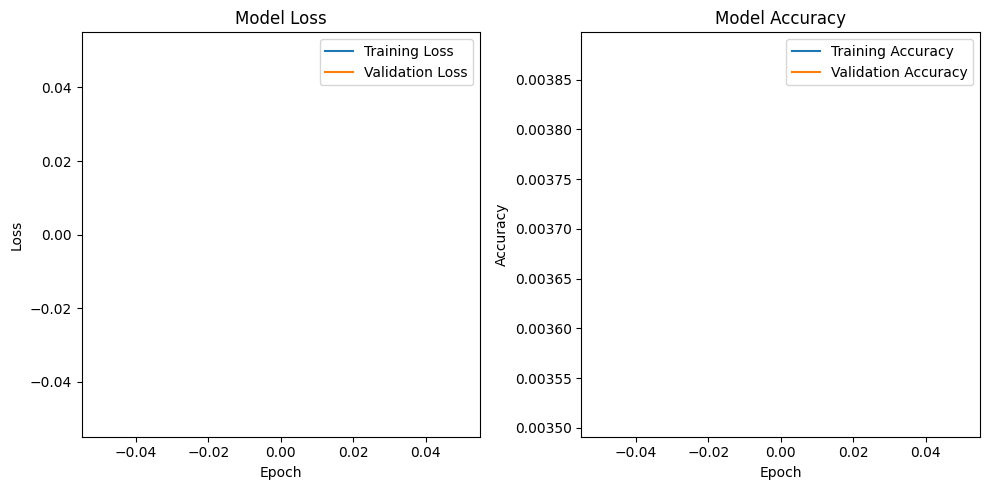

In [82]:
plt.figure(figsize=(15, 5))

# Plot loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()